# World Cup Data Analysis (1994-2026): 4 Questions

**SQL + Python data analysis project** asking four specific, less obvious questions
about the last nine World Cups (1994-2026) — the span between the two tournaments
held in the USA. No "does hosting help" here: this project skips the obvious question
and goes after four things that are more interesting and less asked.

Built on SQL techniques from IBM's **"Databases and SQL for Data Science with
Python"** course (Coursera / IBM Data Science Professional Certificate), applied to
an original dataset compiled via **Gemini Pro Deep Research** and **independently
validated** against primary sources before use — see
[Methodology & Data Validation Log](#methodology).

> **Data snapshot:** tournament complete as of **July 20, 2026**. Spain beat
> Argentina 1-0 in the final; England beat France 6-4 in the third-place match;
> Kylian Mbappé finished as outright top scorer with 10 goals — all reflected in
> the data below.

### The Four Questions

1. Does a World Cup top scorer's club form, right before the tournament, predict
   their scoring form at the Cup?
2. Does the top scorer's team actually win the tournament?
3. Africa (CAF) and Asia (AFC) have gained steadily more World Cup slots since
   1994 — did their *ceiling* (best result) grow at the same pace as their *volume*
   (number of slots)?
4. Do naturalized players show up as a targeted fix for one specific position, or
   as broad squad reinforcement?

---
### Table of Contents
1. [Setup](#setup)
2. [Q1: Does Club Form Predict the Golden Boot?](#q1)
3. [Q2: Does the Top Scorer's Team Win the Title?](#q2)
4. [Q3: CAF/AFC — Ceiling vs. Volume](#q3)
5. [Q4: Naturalized Players as a Surgical Fix](#q4)
6. [Takeaways](#takeaways)
7. [Methodology & Data Validation Log](#methodology)

## 1. Setup <a id='setup'></a>

Load the three datasets into an in-memory SQLite database using the `db_utils` module.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import db_utils

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

conn = db_utils.get_connection()
print("Tables loaded:", db_utils.list_tables(conn))


Tables loaded: ['TOP_SCORERS', 'TEAM_RESULTS', 'NATURALIZED_PLAYERS']


## 2. Q1: Does Club Form Predict the Golden Boot? <a id='q1'></a>

Every World Cup top scorer arrives off a club season. Does a huge club-goals tally
predict who becomes the tournament's top scorer, or is Golden Boot form its own thing?

/sessions/wonderful-blissful-carson/tmp/ipykernel_9/656355522.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scorers, x="YEAR", y="CLUB_GOALS_PRIOR_SEASON", palette="crest")


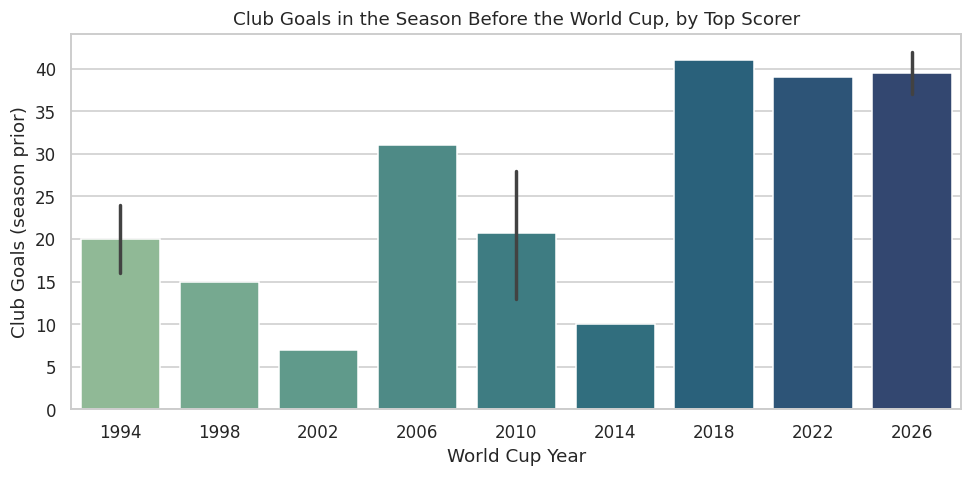

,YEAR,PLAYER_NAME,COUNTRY,WC_GOALS,CLUB_BEFORE_WC,CLUB_GOALS_PRIOR_SEASON
0,1994,Hristo Stoichkov,Bulgária,6,Barcelona,24
1,1994,Oleg Salenko,Rússia,6,CD Logroñés,16
2,1998,Davor Šuker,Croácia,6,Real Madrid,15
3,2002,Ronaldo,Brasil,8,Internazionale,7
4,2006,Miroslav Klose,Alemanha,5,Werder Bremen,31
5,2010,Thomas Müller,Alemanha,5,Bayern de Munique,19
6,2010,David Villa,Espanha,5,Valencia CF,28
7,2010,Wesley Sneijder,Holanda,5,Internazionale,8
8,2010,Diego Forlán,Uruguai,5,Atlético de Madrid,28
9,2014,James Rodríguez,Colômbia,6,AS Monaco,10


In [2]:
query = """
SELECT YEAR, PLAYER_NAME, COUNTRY, WC_GOALS, CLUB_BEFORE_WC, CLUB_GOALS_PRIOR_SEASON
FROM TOP_SCORERS
ORDER BY YEAR;
"""
scorers = db_utils.run_query(conn, query)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=scorers, x="YEAR", y="CLUB_GOALS_PRIOR_SEASON", palette="crest")
plt.title("Club Goals in the Season Before the World Cup, by Top Scorer")
plt.xlabel("World Cup Year")
plt.ylabel("Club Goals (season prior)")
plt.tight_layout()
plt.show()

scorers


**Insight:** club form ranges wildly — from **7 goals** (Ronaldo, 2002, limited by
injuries all season) to **42 goals** (Mbappé, 2025-26) — with no consistent floor.
Ronaldo's case is the sharpest counterexample: the *fewest* club goals of anyone on this
list, yet the outright Golden Boot with 8. Big club seasons (Harry Kane's 41, Mbappé's
39 and 42) do show up among the artilheiros, but so do middling ones (James Rodríguez's
10, Wesley Sneijder's 8). **Club form is not a reliable predictor of who wins the World
Cup's scoring title** — it correlates loosely with being a world-class striker in the
first place, not with peaking at the tournament itself.

## 3. Q2: Does the Top Scorer's Team Win the Title? <a id='q2'></a>

Joining `TOP_SCORERS` with `TEAM_RESULTS` on year + country answers a simple but
under-asked question: how often does the individual Golden Boot winner's team actually
lift the trophy?

/sessions/wonderful-blissful-carson/tmp/ipykernel_9/2463821564.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="team_outcome", y="num_editions", palette="flare")


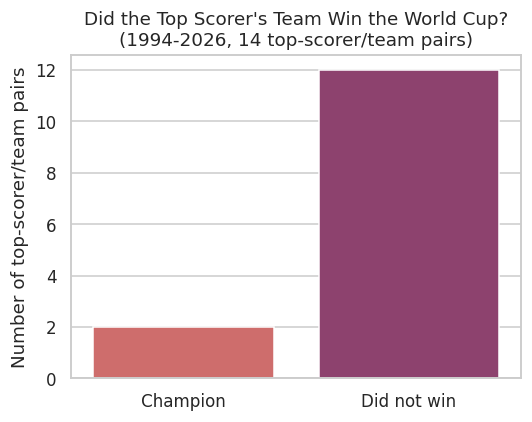

,YEAR,PLAYER_NAME,COUNTRY,WC_GOALS,STAGE_REACHED
0,1994,Hristo Stoichkov,Bulgária,6,Quarto Lugar
1,1994,Oleg Salenko,Rússia,6,Fase de Grupos
2,1998,Davor Šuker,Croácia,6,Terceiro Lugar
3,2002,Ronaldo,Brasil,8,Campeão
4,2006,Miroslav Klose,Alemanha,5,Terceiro Lugar
5,2010,Thomas Müller,Alemanha,5,Terceiro Lugar
6,2010,David Villa,Espanha,5,Campeão
7,2010,Wesley Sneijder,Holanda,5,Vice-campeão
8,2010,Diego Forlán,Uruguai,5,Quarto Lugar
9,2014,James Rodríguez,Colômbia,6,Quartos de final


In [3]:
query = """
SELECT ts.YEAR, ts.PLAYER_NAME, ts.COUNTRY, ts.WC_GOALS, tr.STAGE_REACHED
FROM TOP_SCORERS ts
JOIN TEAM_RESULTS tr ON ts.YEAR = tr.YEAR AND ts.COUNTRY = tr.TEAM
ORDER BY ts.YEAR;
"""
scorer_outcomes = db_utils.run_query(conn, query)

query_summary = """
SELECT
    CASE WHEN tr.STAGE_REACHED = 'Campeão' THEN 'Champion' ELSE 'Did not win' END AS team_outcome,
    COUNT(*) AS num_editions
FROM TOP_SCORERS ts
JOIN TEAM_RESULTS tr ON ts.YEAR = tr.YEAR AND ts.COUNTRY = tr.TEAM
GROUP BY team_outcome;
"""
summary = db_utils.run_query(conn, query_summary)

plt.figure(figsize=(5, 4))
sns.barplot(data=summary, x="team_outcome", y="num_editions", palette="flare")
plt.title("Did the Top Scorer's Team Win the World Cup?\n(1994-2026, 14 top-scorer/team pairs)")
plt.xlabel("")
plt.ylabel("Number of top-scorer/team pairs")
plt.tight_layout()
plt.show()

scorer_outcomes


**Insight:** across 14 top-scorer/team pairs since 1994 (counting every player in a
tie), the scorer's team was champion only **twice** — Ronaldo's Brazil in 2002 and
David Villa's Spain in 2010. Everyone else's team fell short, including 2026's Kylian
Mbappé: a record-setting 10 goals and an outright Golden Boot, on a France squad that
finished **fourth**. Being the tournament's best individual finisher and lifting the
trophy are, empirically, two mostly unrelated achievements — which is itself the more
interesting story than "the best scorer's team usually wins," the assumption this
question set out to test.

## 4. Q3: CAF/AFC — Ceiling vs. Volume <a id='q3'></a>

Africa (CAF) and Asia (AFC) have both received steadily more World Cup slots since
1994 — genuine volume growth. This question asks whether their *ceiling* (best result
reached in a given edition) grew at the same pace, using an ordinal stage-rank scale
(1 = Champion ... 7 = Group Stage, with 6.5 for the new 2026 "Round of 32").

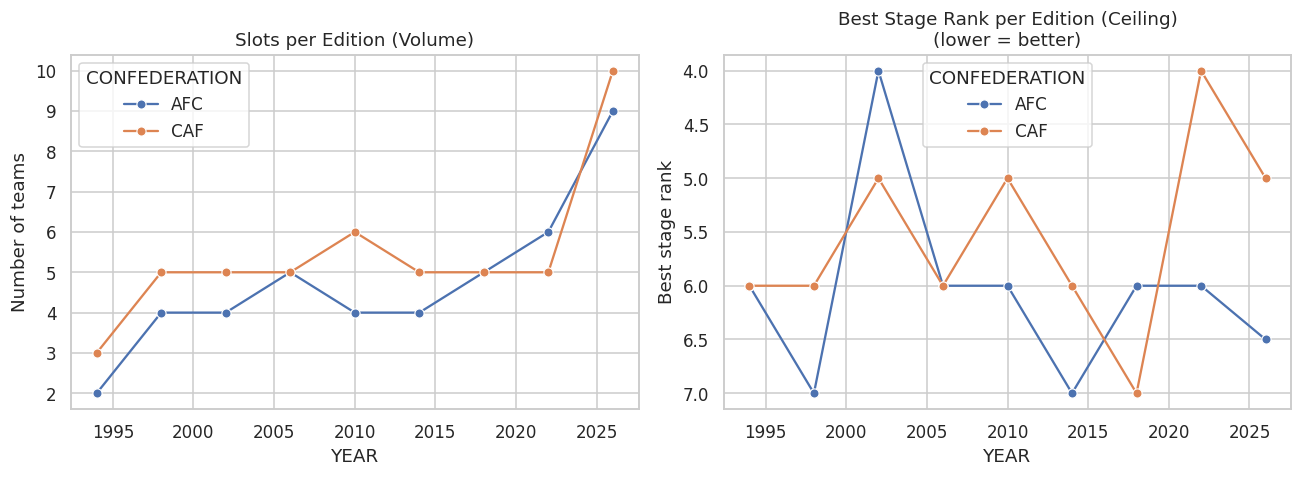

,YEAR,CONFEDERATION,NUM_VAGAS,MELHOR_RANK
0,1994,AFC,2,6.0
1,1998,AFC,4,7.0
2,2002,AFC,4,4.0
3,2006,AFC,5,6.0
4,2010,AFC,4,6.0
5,2014,AFC,4,7.0
6,2018,AFC,5,6.0
7,2022,AFC,6,6.0
8,2026,AFC,9,6.5
9,1994,CAF,3,6.0


In [4]:
RANK_CASE = """CASE STAGE_REACHED
    WHEN 'Campeão' THEN 1
    WHEN 'Vice-campeão' THEN 2
    WHEN 'Terceiro Lugar' THEN 3
    WHEN 'Quarto Lugar' THEN 4
    WHEN 'Quartos de final' THEN 5
    WHEN 'Oitavos de final' THEN 6
    WHEN '16 avos de final' THEN 6.5
    WHEN 'Fase de Grupos' THEN 7
END"""

query = f"""
SELECT slots.YEAR, slots.CONFEDERATION, slots.NUM_VAGAS, ceiling.MELHOR_RANK
FROM (
    SELECT YEAR, CONFEDERATION, COUNT(*) AS NUM_VAGAS
    FROM TEAM_RESULTS
    WHERE CONFEDERATION IN ('CAF', 'AFC')
    GROUP BY YEAR, CONFEDERATION
) slots
JOIN (
    SELECT YEAR, CONFEDERATION, MIN({RANK_CASE}) AS MELHOR_RANK
    FROM TEAM_RESULTS
    WHERE CONFEDERATION IN ('CAF', 'AFC')
    GROUP BY YEAR, CONFEDERATION
) ceiling
ON slots.YEAR = ceiling.YEAR AND slots.CONFEDERATION = ceiling.CONFEDERATION
ORDER BY slots.CONFEDERATION, slots.YEAR;
"""
ceiling_vs_volume = db_utils.run_query(conn, query)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(data=ceiling_vs_volume, x="YEAR", y="NUM_VAGAS", hue="CONFEDERATION", marker="o", ax=axes[0])
axes[0].set_title("Slots per Edition (Volume)")
axes[0].set_ylabel("Number of teams")

sns.lineplot(data=ceiling_vs_volume, x="YEAR", y="MELHOR_RANK", hue="CONFEDERATION", marker="o", ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title("Best Stage Rank per Edition (Ceiling)\n(lower = better)")
axes[1].set_ylabel("Best stage rank")

plt.tight_layout()
plt.show()

ceiling_vs_volume


**Insight:** volume growth is real and steady — AFC slots went from 2 (1994) to 9
(2026); CAF from 3 to 10. The ceiling did **not** grow in step. AFC's best-ever result
in this window is still South Korea's semifinal in **2002** (rank 4) — a year with only
4 AFC slots, fewer than most later editions. CAF's best-ever result is Morocco's
semifinal in **2022** (rank 4), with just 5 slots. In 2026, with roughly double the
slots of any prior edition, neither confederation matched that ceiling: AFC's best was
a Round of 32 exit, CAF's best a quarterfinal. **More seats at the table did not, on
this evidence, translate into a higher ceiling** — the confederations are qualifying
more teams, not (yet) more contenders.

## 5. Q4: Naturalized Players as a Surgical Fix <a id='q4'></a>

Rather than a full squad census (unreliable at scale), this question focuses on the
**36 most-documented, press-covered cases** of naturalized players (naturalized by
residency, not ancestry) who were key contributors for their adopted national team.
Does the pattern look like broad squad reinforcement, or a targeted fix for a specific
positional gap?

/sessions/wonderful-blissful-carson/tmp/ipykernel_9/4248168721.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=positions, x="position_group", y="num_cases", palette="mako")


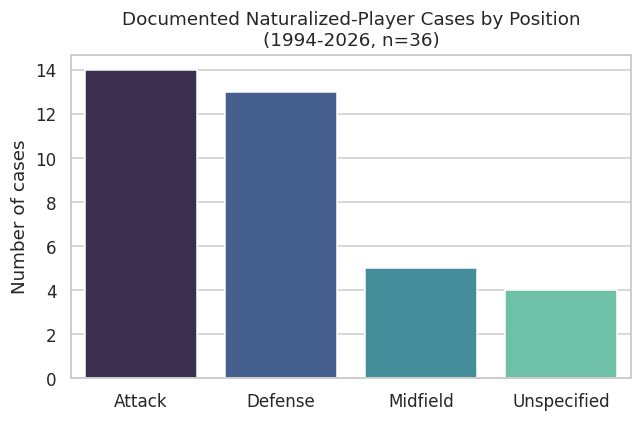

,position_group,num_cases
0,Attack,14
1,Defense,13
2,Midfield,5
3,Unspecified,4


In [5]:
query_position = """
SELECT
    CASE
        WHEN WAS_KEY_PLAYER LIKE '%agueiro%' OR WAS_KEY_PLAYER LIKE '%ateral%'
             OR WAS_KEY_PLAYER LIKE '%olante%' OR WAS_KEY_PLAYER LIKE '%efensor%'
             OR WAS_KEY_PLAYER LIKE '%a defesa%' THEN 'Defense'
        WHEN WAS_KEY_PLAYER LIKE '%tacante%' OR WAS_KEY_PLAYER LIKE '%entroavante%'
             OR WAS_KEY_PLAYER LIKE '%rtilheiro%' OR WAS_KEY_PLAYER LIKE '%ofensiv%'
             OR WAS_KEY_PLAYER LIKE '%e ataque%' THEN 'Attack'
        WHEN WAS_KEY_PLAYER LIKE '%eia %' OR WAS_KEY_PLAYER LIKE '%rmador%'
             OR WAS_KEY_PLAYER LIKE '%laymaker%' OR WAS_KEY_PLAYER LIKE '%rticulador%'
             OR WAS_KEY_PLAYER LIKE '%eio-campo%' THEN 'Midfield'
        ELSE 'Unspecified'
    END AS position_group,
    COUNT(*) AS num_cases
FROM NATURALIZED_PLAYERS
GROUP BY position_group
ORDER BY num_cases DESC;
"""
positions = db_utils.run_query(conn, query_position)

plt.figure(figsize=(6, 4))
sns.barplot(data=positions, x="position_group", y="num_cases", palette="mako")
plt.title("Documented Naturalized-Player Cases by Position\n(1994-2026, n=36)")
plt.xlabel("")
plt.ylabel("Number of cases")
plt.tight_layout()
plt.show()

positions


**Insight:** defense (13) and clear-cut finishing/attack roles (14) together account
for 27 of the 36 documented cases — the pattern looks far more like teams patching a
specific hole (a missing ball-playing centre-back, a striker who can actually score)
than a broad wave of reinforcements across the XI. Marc Guéhi's role in England's back
line and Aymeric Laporte anchoring Spain's defense through their 2026 title both fit
this pattern exactly: a specific structural need, filled by one player, rather than a
squad built around naturalized talent.

## 6. Takeaways <a id='takeaways'></a>

- **Club form does not predict the Golden Boot.** Ronaldo won it in 2002 with the
  *fewest* club goals of anyone in the dataset (7, injury-limited); Mbappé's
  record-setting 2026 haul came off the *most* club goals (42). No consistent floor.
- **The top scorer's team almost never wins the title.** Only 2 of 14 top-scorer/team
  pairs since 1994 ended in a championship. Mbappé's 2026 Golden Boot came with France
  finishing fourth — the sharpest recent illustration of the split.
- **CAF/AFC slot growth has not moved the ceiling.** Both confederations roughly
  doubled or tripled their slot counts since 1994, but their best-ever results (South
  Korea 2002, Morocco 2022) happened in editions with *fewer* slots than 2026, where
  neither matched that ceiling despite the largest allocation in history.
- **Naturalization reads as a targeted fix, not a trend.** 27 of 36 documented cases
  are defenders or attackers solving one specific problem for their adopted team, not
  evidence of squads being broadly rebuilt around naturalized players.

---

## 7. Methodology & Data Validation Log <a id='methodology'></a>

- **Compiled via Gemini Pro Deep Research**, using three schema-first prompts (exact
  CSV column headers specified up front, explicit source-citation and
  confidence-flagging instructions, and a strict definition of "naturalized" —
  residency/civil-process naturalization only, excluding ancestry-based eligibility
  such as Miroslav Klose's German repatriation or Morocco's diaspora players).
- **Independently validated before use, not taken at face value.** Every dataset was
  cross-checked against primary sources before being loaded into this project. Two
  concrete errors were caught and fixed this way — see the log below.
- **`NATURALIZED_PLAYERS` is a curated set of the most-documented, press-covered
  cases, not an exhaustive squad census** — deliberately scoped down from an
  unreliable full count to a smaller set of verifiable cases.
- **2026 data:** tournament complete as of **July 20, 2026** — all results final,
  including the Spain 1-0 Argentina final and the England 6-4 France third-place match.
- **Language note:** team names, stage labels, and note fields are in Portuguese (the
  language the Deep Research was conducted in and the language of most cited sources);
  this notebook's narrative text is in English for consistency with the README.

### Correction log

Two real errors were found and fixed during this project, each through a different
validation method — a deliberate part of the portfolio story, not an incidental detail:

1. **Two non-qualified teams in the 2026 `TEAM_RESULTS` data.** The Deep Research
   output included Cameroon and Costa Rica as 2026 participants, which would have made
   the tournament 50 teams instead of 48. A simple row-count check (`Counter(year)`
   showing 50 for 2026) flagged the discrepancy; cross-referencing Wikipedia's "List of
   team base camps" table (one row per actually-qualified team) confirmed both were
   false inclusions and both were removed.
2. **A player who never played the tournament.** The naturalized-players research
   included Robin Le Normand as a starting centre-back for Spain's actual 2026 World
   Cup squad. A targeted web search confirmed he was not selected for the World Cup
   squad at all (only for Euro 2024) — the row was removed.

### Tech Stack

`Python` · `SQLite` · `pandas` · `matplotlib` · `seaborn` · SQL (joins, subqueries,
`CASE`, aggregate functions, `GROUP BY`) · Gemini Pro Deep Research (data compilation,
independently validated)

### Course Credit

SQL techniques applied in this notebook (joins, subqueries, aggregate functions,
`GROUP BY`/`ORDER BY`, `CASE` statements) were learned in IBM's **"Databases and SQL
for Data Science with Python"** course (Coursera / IBM Data Science Professional
Certificate). All datasets, queries, and analysis are original work built for this
portfolio project.